In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_INTERIM.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)

/Users/modjrin1/Library/CloudStorage/OneDrive-AaltoUniversity/paper 4 - mobility spain/heat-conditioned-accessibility


In [2]:
boundary = gpd.read_file(DATA_RAW / "sevilla_boundary.gpkg")
buildings = gpd.read_file(DATA_RAW / "sevilla_buildings.gpkg")

boundary.crs, buildings.crs

(<Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

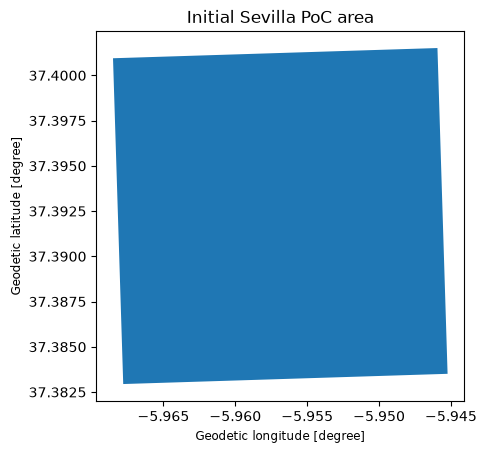

In [3]:
boundary_proj = boundary.to_crs(boundary.estimate_utm_crs())

centroid = boundary_proj.geometry.centroid.iloc[0]

test_area_proj = gpd.GeoDataFrame(
    geometry=[centroid.buffer(1000).envelope],
    crs=boundary_proj.crs
)

test_area = test_area_proj.to_crs(4326)

test_area.plot()
plt.title("Initial Sevilla PoC area")
plt.show()

In [4]:
import voxcity
print("VoxCity imported successfully")
from voxcity.generator import get_voxcity

VoxCity imported successfully


In [5]:
minx, miny, maxx, maxy = test_area.total_bounds

rectangle_vertices = [
    (minx, miny),
    (minx, maxy),
    (maxx, maxy),
    (maxx, miny),
]

rectangle_vertices

[(np.float64(-5.96850346486674), np.float64(37.38294295915931)),
 (np.float64(-5.96850346486674), np.float64(37.40151128213675)),
 (np.float64(-5.9452312992316525), np.float64(37.40151128213675)),
 (np.float64(-5.9452312992316525), np.float64(37.38294295915931))]

INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_source, land_cover_source, canopy_height_source, dem_source, building_complementary_source


Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (-5.9569, 37.3922): Spain
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=Microsoft Building Footprints | https://github.com/microsoft/GlobalMLBuildingFootprints
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - DEM=Flat
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
INFO | voxcity.voxcity.utils.cache | Cache read failed for load_gdf_from_openstreetmap ((<StringDtype(storage='python', na_value=nan)>, array(['default', 'default', 'default', ..., 'levels', 'default',
       'default'], shape=(1520,), dtype=object))); re-downloading
INFO | voxcity.voxcity.


  • Land Cover:  OpenStreetMap
  • Building:    OpenStreetMap
  • Canopy:      OpenStreetMap
  • DEM:         Flat
------------------------------------------------------------
Downloading... (this may take a moment)
  ✓ Dem complete (1/4)
Fetching data from Overpass API...


INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: server error (HTTP 504) from https://overpass-api.de/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: server error (HTTP 504) from https://overpass-api.de/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: server error (HTTP 504) from https://overpass-api.de/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: timeout after 60s from https://overpass.kumi.systems/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: timeout after 60s from https://overpass.kumi.systems/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: timeout after 60s from https://overpass.kumi.systems/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Overpass endpoint unreachable, marking dead for this call: https://overpass.openstreetmap.ru/api/interpreter (HTTPSConnectionPool(host='overpass.openstreetm

...

  Downloaded 716 individual trees and 6 tree polygons from OSM
  Downloaded 722 trees from OSM
  Created canopy grids: (412, 412)
  ✓ Canopy complete (2/4)


INFO | voxcity.voxcity.downloader.utils | File downloaded successfully and saved as output/dataset-links.csv
INFO | voxcity.voxcity.downloader.utils | File downloaded successfully and saved as output/Spain_033110331.gz
INFO | voxcity.voxcity.geoprocessor.raster.buildings | 1407 of the total 1520 building footprint from the base data source did not have height data.
INFO | voxcity.voxcity.geoprocessor.heights | For 0 of these building footprints without height, values from the complementary source were assigned.
INFO | voxcity.voxcity.geoprocessor.heights | For 1407 of these building footprints without height, no data exist in complementary data.


  ✓ Building complete (3/4)


INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: timeout after 60s from https://overpass.kumi.systems/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Retry 2/4: waiting 10.0s before next attempt...
INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: server error (HTTP 504) from https://overpass-api.de/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: timeout after 60s from https://overpass.kumi.systems/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Retry 3/4: waiting 20.0s before next attempt...


Converting data to GeoJSON format...
  ✓ Land Cover complete (4/4)
------------------------------------------------------------
All downloads complete!



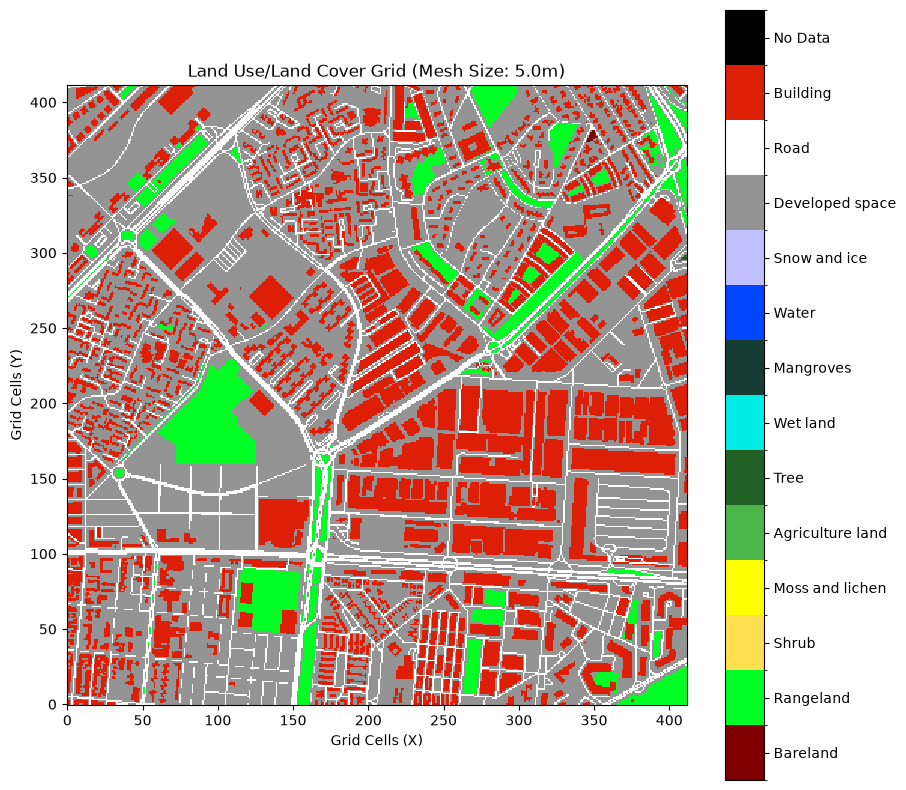

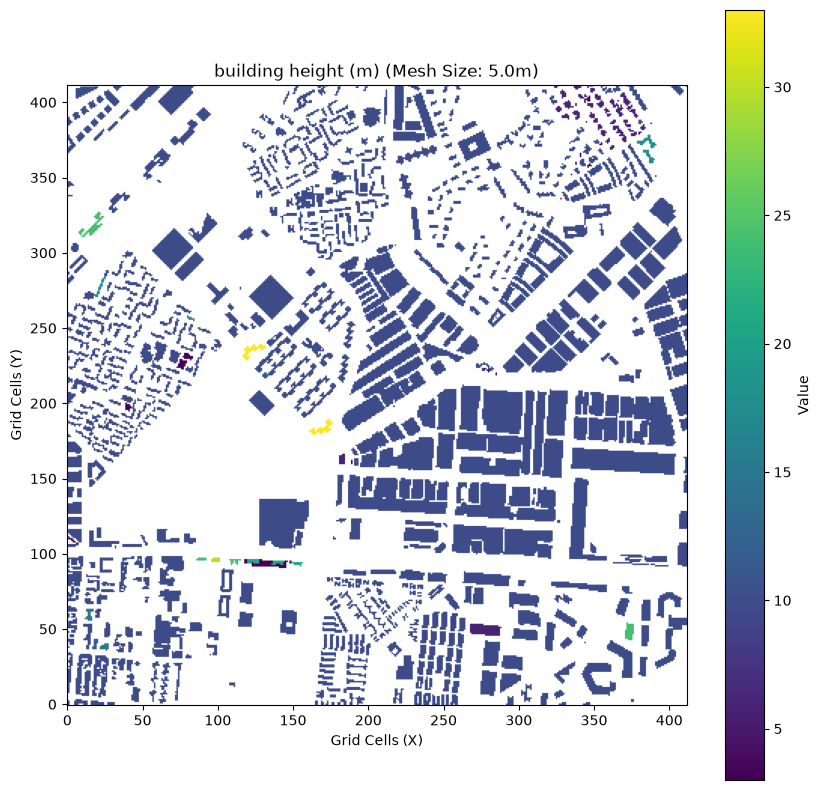

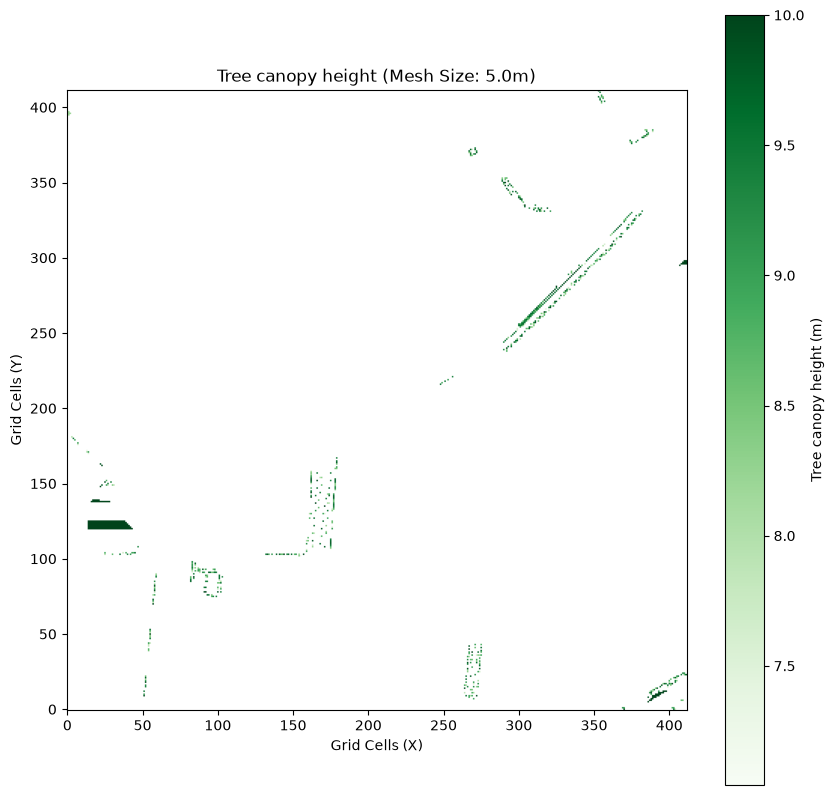

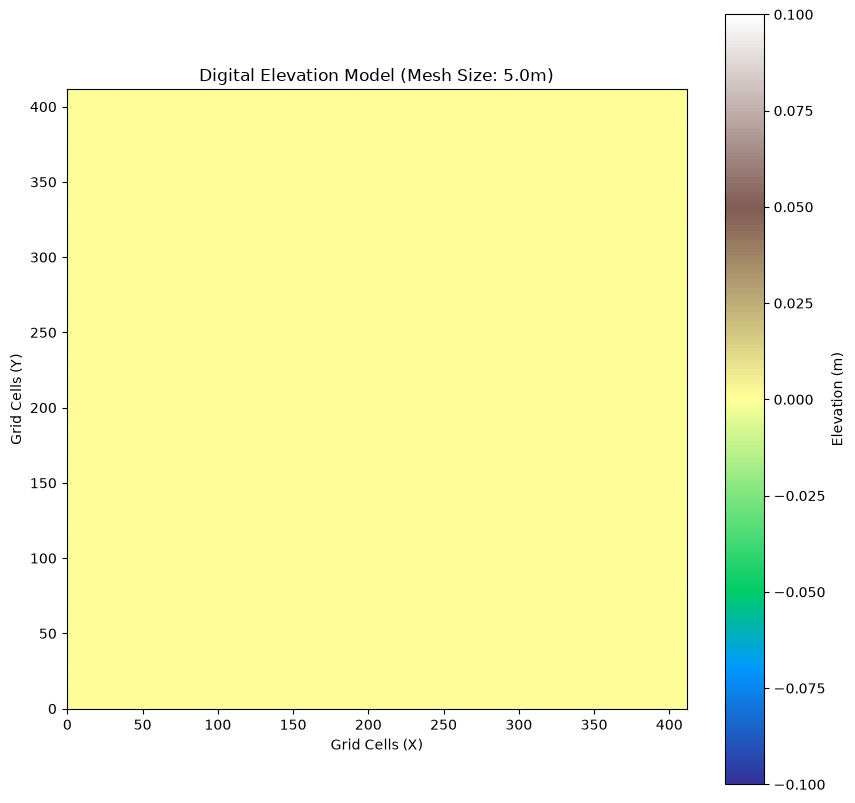

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity results saved to output/voxcity.h5


In [6]:
voxcity_model = get_voxcity(
    rectangle_vertices,
    meshsize=5
)

In [7]:
type(voxcity_model)


voxcity.models.VoxCity

In [8]:
dir(voxcity_model)


['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'buildings',
 'dem',
 'extras',
 'land_cover',
 'to_xarray',
 'tree_canopy',
 'voxels']

In [9]:
print(voxcity_model)

VoxCity(voxels=VoxelGrid(classes=array([[[13, -3, -3, ...,  0,  0,  0],
        [13, -3, -3, ...,  0,  0,  0],
        [11,  0,  0, ...,  0,  0,  0],
        ...,
        [ 2,  0,  0, ...,  0,  0,  0],
        [ 2,  0,  0, ...,  0,  0,  0],
        [ 2,  0,  0, ...,  0,  0,  0]],

       [[13, -3, -3, ...,  0,  0,  0],
        [13, -3, -3, ...,  0,  0,  0],
        [11,  0,  0, ...,  0,  0,  0],
        ...,
        [ 2,  0,  0, ...,  0,  0,  0],
        [ 2,  0,  0, ...,  0,  0,  0],
        [ 2,  0,  0, ...,  0,  0,  0]],

       [[13, -3, -3, ...,  0,  0,  0],
        [13, -3, -3, ...,  0,  0,  0],
        [11,  0,  0, ...,  0,  0,  0],
        ...,
        [ 2,  0,  0, ...,  0,  0,  0],
        [ 2,  0,  0, ...,  0,  0,  0],
        [ 2,  0,  0, ...,  0,  0,  0]],

       ...,

       [[11,  0,  0, ...,  0,  0,  0],
        [11,  0,  0, ...,  0,  0,  0],
        [11,  0,  0, ...,  0,  0,  0],
        ...,
        [11,  0,  0, ...,  0,  0,  0],
        [11,  0,  0, ...,  0,  0,  0],

In [10]:
import solweig

print(solweig.__version__ if hasattr(solweig, "__version__") else "SOLWEIG imported")

2026-10-06 17:35:34,624 - INFO - Using rasterio for raster operations.


0.1.0b96


In [11]:
solweig.SurfaceData.prepare(...)

ValueError: working_dir is required when dsm is a file path